In [2]:
%load_ext autoreload

In [3]:
%autoreload 2
# import libraries
import glob
import numpy as np
import pandas as pd
import cv2 as cv
from skimage import io
from PIL import Image
import matplotlib.pylab as plt
from skimage.transform import downscale_local_mean, pyramid_expand, resize

## Get MRI image

In [4]:
mri_img_list = glob.glob("../data/sent_by_marcus/*.tif")
print(mri_img_list)

['../data/sent_by_marcus/Subsection_234.tif', '../data/sent_by_marcus/AVG_Substack (230-234).tif']


In [5]:
# choose the average one from Marcus
mri_img_path = mri_img_list[1]
print(mri_img_path)

../data/sent_by_marcus/AVG_Substack (230-234).tif


image shape: (35, 41)


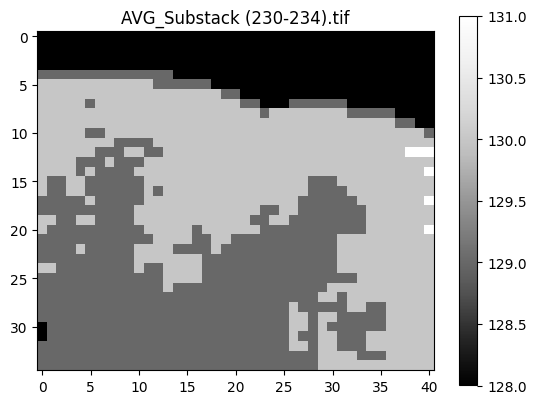

In [6]:
mri_img = cv.imread(mri_img_path, cv.IMREAD_GRAYSCALE)
mri_img_title = mri_img_path.split('/')[-1]
print(f"image shape: {mri_img.shape}")

plt.figure()
plt.imshow(mri_img, cmap='Greys_r')
plt.title(mri_img_title)
plt.colorbar()

In [7]:
type(mri_img)

numpy.ndarray

## Get histology slide image

In [8]:
slide_img_list = glob.glob("../data/*.tif")
print(slide_img_list)

['../data/GWIN2000662_2222.tif', '../data/GWIN2000516_5328.tif', '../data/GWIN2000662_2221.tif', '../data/GWIN2000662_2220.tif', '../data/GWIN2000516_5329.tif', '../data/GWIN2000662_2218.tif', '../data/GWIN2000662_2219.tif', '../data/GWIN2000516_5330.tif', '../data/GWIN2000516_5331.tif']


In [9]:
slide_img_path = slide_img_list[-1]
print(slide_img_path)

../data/GWIN2000516_5331.tif


image shape: (3685, 1251)


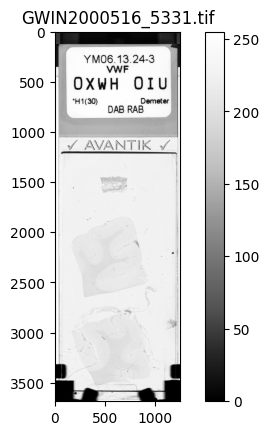

In [10]:
slide_img = cv.imread(slide_img_path, cv.IMREAD_GRAYSCALE)
slide_img_title = slide_img_path.split('/')[-1]
print(f"image shape: {slide_img.shape}")

plt.imshow(slide_img, cmap='Greys_r')
plt.title(slide_img_title)
plt.colorbar()

cropped_image shape: (900, 951)


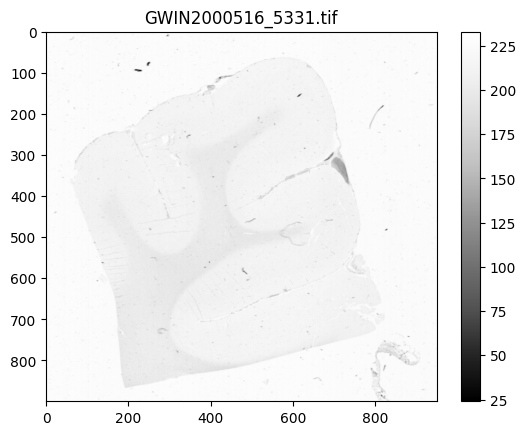

In [11]:
# Crop around area of interest
cropped_img = slide_img[-1900:-1000,100:-200]
print(f"cropped_image shape: {cropped_img.shape}")

plt.imshow(cropped_img, cmap='Greys_r')
plt.title(slide_img_title)
plt.colorbar()

## Show images side by side

In [12]:
def compare_plot(mri_img, slide_img):
    plt.figure(figsize=(15,5))

    plt.subplot(1, 2, 1)
    plt.imshow(mri_img, cmap='Greys_r')
    plt.title(mri_img_title)
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.imshow(slide_img, cmap='Greys_r')
    plt.title(slide_img_title)
    plt.colorbar()


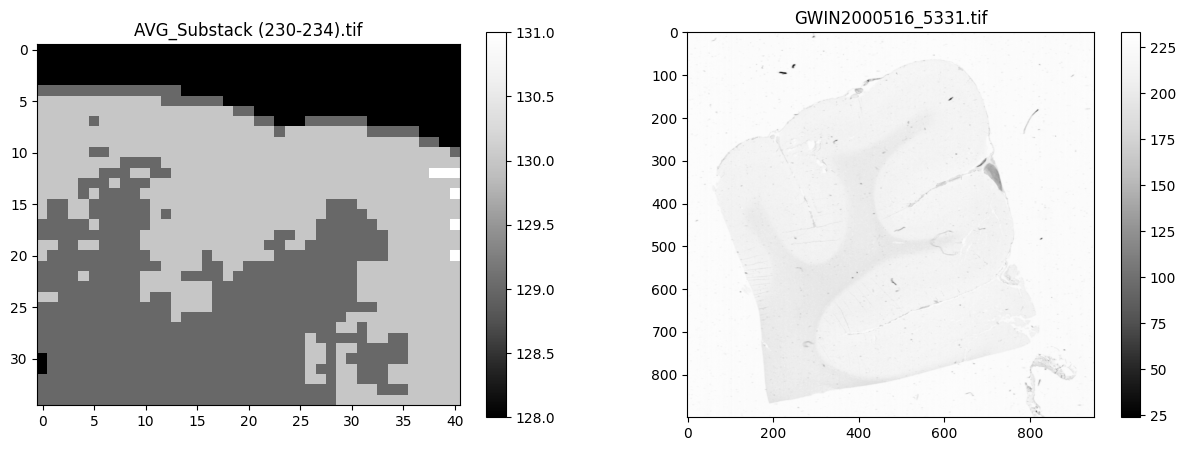

In [13]:
compare_plot(mri_img=mri_img, slide_img=cropped_img)

## Intensity scaling 

In [14]:
# CLAHE: Contrast Limited Adaptive Histogram Equalization)
# improves local contrast and enhances the definition of edges in images.
clahe = cv.createCLAHE(clipLimit=5.0, tileGridSize=(8, 8))
clahe_img = clahe.apply(cropped_img)


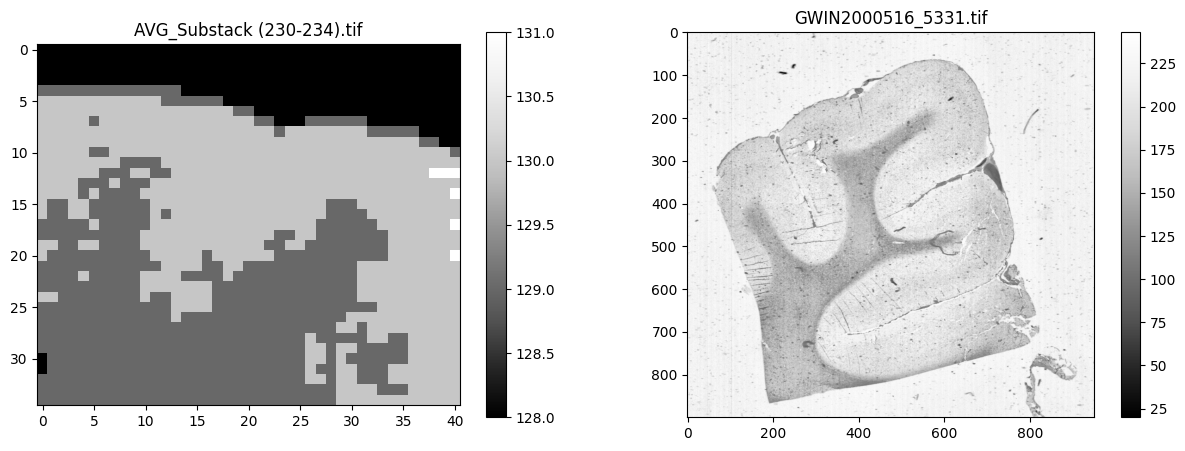

In [15]:
compare_plot(mri_img=mri_img, slide_img=clahe_img)

## Blurring

In [16]:
# Kernel size must be odd
median_filtered_img = cv.medianBlur(clahe_img, ksize=31)  

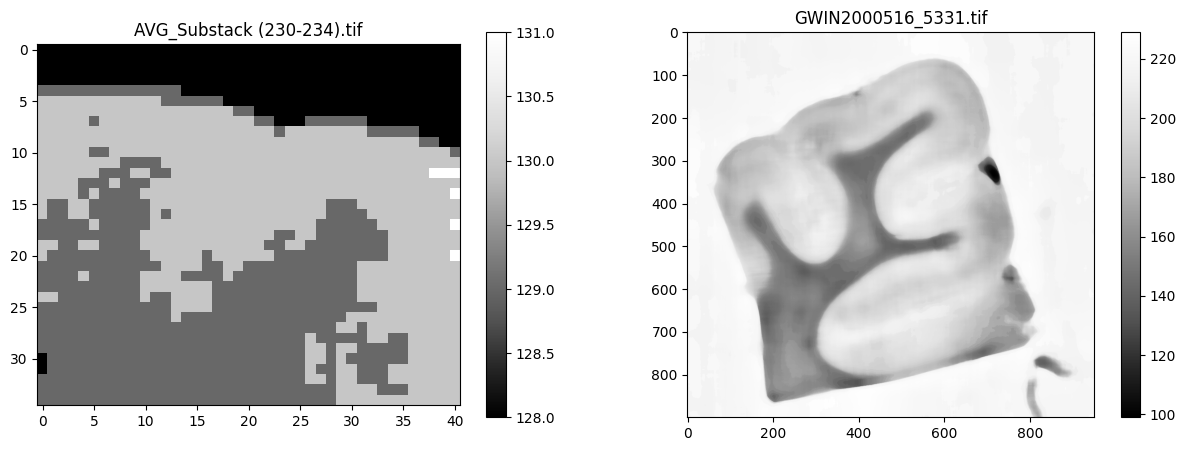

In [17]:
compare_plot(mri_img=mri_img, slide_img=median_filtered_img)

## Downscaling

!!! Would need to know the size of pixels in the histology slide images to downscale them to the same resolution as the MRI.

In [ ]:
MRI_total_width = 120012.80
MRI_total_height = 59999.82
MRI_total_pix_width = 512
MRI_total_pix_height = 200
MRI_pixel_width = MRI_total_width / MRI_total_pix_width
MRI_pixel_height = MRI_total_height / MRI_total_pix_height
print(f"MRI_pixel_width: {round(MRI_pixel_width, 2)} microns")
print(f"MRI_pixel_height: {round(MRI_pixel_height, 2)} microns")

slide_total_pix_width = cropped_img.shape[1]
slide_total_pix_height = cropped_img.shape[0]
slide_pix_size = 0.4650
slide_total_width = slide_pix_size * slide_total_pix_width
slide_total_height = slide_pix_size * slide_total_pix_height
print(f"slide_total_width: {round(slide_total_width,2)} microns")
print(f"slide_total_height: {round(slide_total_height,2)} microns")


MRI_pixel_width: 234.4 microns
MRI_pixel_height: 300.0 microns
slide_total_width: 442.22 microns
slide_total_height: 418.5 microns


Rescaling the microscope slide to match the MRI resolution.

In [19]:
scaling_width_ratio = MRI_pixel_width / slide_pix_size
scaling_height_ratio = MRI_pixel_height / slide_pix_size

print(f"scaling_width_ratio: {scaling_width_ratio}")
print(f"scaling_height_ratio: {scaling_height_ratio}")

# testing
print(f"New pixel width size for microscope slides: {slide_pix_size * scaling_width_ratio}")
print(f"New pixel heith size for microscope slides: {slide_pix_size * scaling_height_ratio}")

scaling_width_ratio: 504.0860215053763
scaling_height_ratio: 645.1593548387096
New pixel width size for microscope slides: 234.4
New pixel heith size for microscope slides: 299.9991


downscaled_image shape: (2, 2)


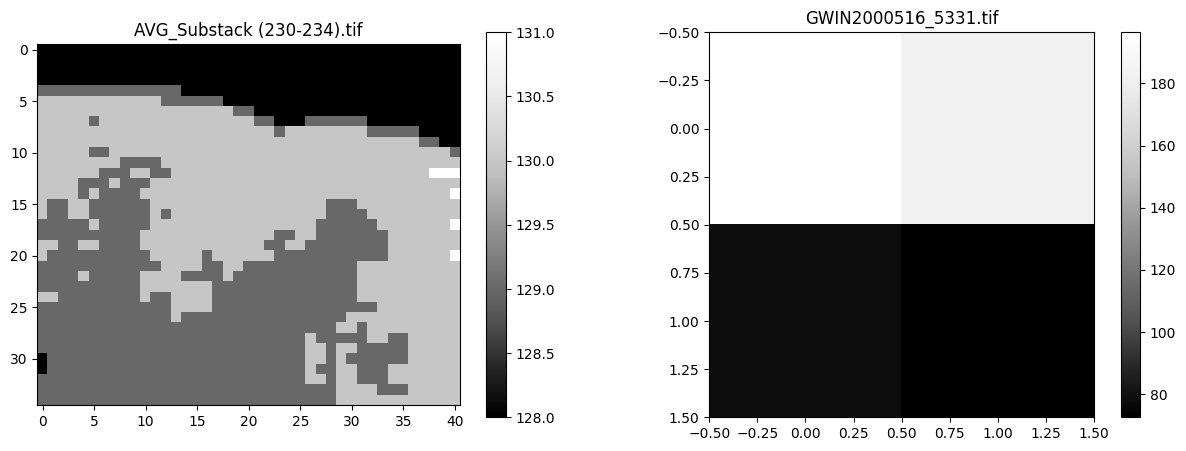

In [20]:
# Downscale by a factor of array of integers (adjust as needed)
# doc here: https://scikit-image.org/docs/stable/api/skimage.transform.html#skimage.transform.downscale_local_mean
downscaled_img = downscale_local_mean(median_filtered_img, factors=(int(scaling_height_ratio), int(scaling_width_ratio)))  # Assuming a 3D image (height, width, channels)
print(f"downscaled_image shape: {downscaled_img.shape}")

compare_plot(mri_img=mri_img, slide_img=downscaled_img)

It seems we cannot downscale the microscope slide to match the MRI resolution. If we do so, we would end up with a 4 pixel image.

Let's try instead: 
- match MRI resolution to the microscope slide   <------- crashed my kernel
- or find an intermediate resolution 

In [21]:
scaling_width_ratio =  MRI_pixel_width / slide_pix_size
scaling_height_ratio = MRI_pixel_height / slide_pix_size

print(f"scaling_width_ratio: {scaling_width_ratio}")
print(f"scaling_height_ratio: {scaling_height_ratio}")


scaling_width_ratio: 504.0860215053763
scaling_height_ratio: 645.1593548387096


downscaled_image shape: (1750, 2050)


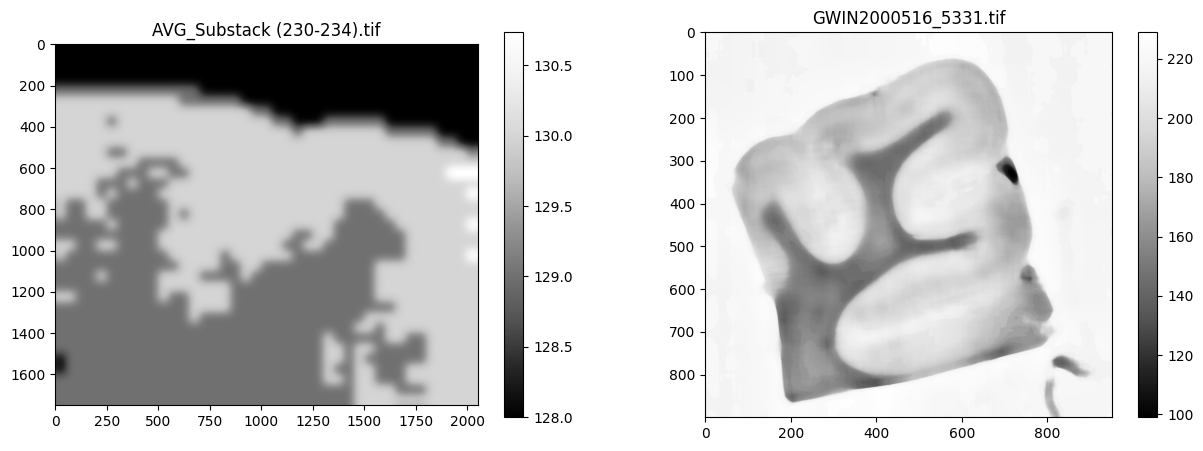

In [44]:
# Upscale MRI
# doc here: https://scikit-image.org/docs/stable/api/skimage.transform.html#skimage.transform.pyramid_expand

#upscaled_mri_img = pyramid_expand(mri_img, upscale=scaling_width_ratio, preserve_range = True)
upscale_ratio = 50
upscaled_mri_img = pyramid_expand(mri_img, upscale=upscale_ratio, preserve_range = True)  
print(f"downscaled_image shape: {upscaled_mri_img.shape}")

compare_plot(mri_img=upscaled_mri_img, slide_img=median_filtered_img)

In [45]:
scaling_width_ratio = (MRI_pixel_width/upscale_ratio)  / slide_pix_size
scaling_height_ratio = (MRI_pixel_height/upscale_ratio) / slide_pix_size

print(f"scaling_width_ratio: {scaling_width_ratio}")
print(f"scaling_height_ratio: {scaling_height_ratio}")

scaling_width_ratio: 10.081720430107525
scaling_height_ratio: 12.903187096774193


#### downscale histology slide to reach same resolution as upscale MRI
**Method 1:** 
- downsampling with an integer factor with `skimage.transform.downscale_local_mean`.
    - source: https://scikit-image.org/docs/stable/api/skimage.transform.html#skimage.transform.downscale_local_mean
- try `skimage.transform.resize`: performs interpolation to up-size or down-size N-dimensional images. Anti-aliasing should be enabled when down-sizing images to avoid aliasing artifacts.
    - source: https://scikit-image.org/docs/stable/api/skimage.transform.html#skimage.transform.resize

downscaled_image shape: (75, 96)


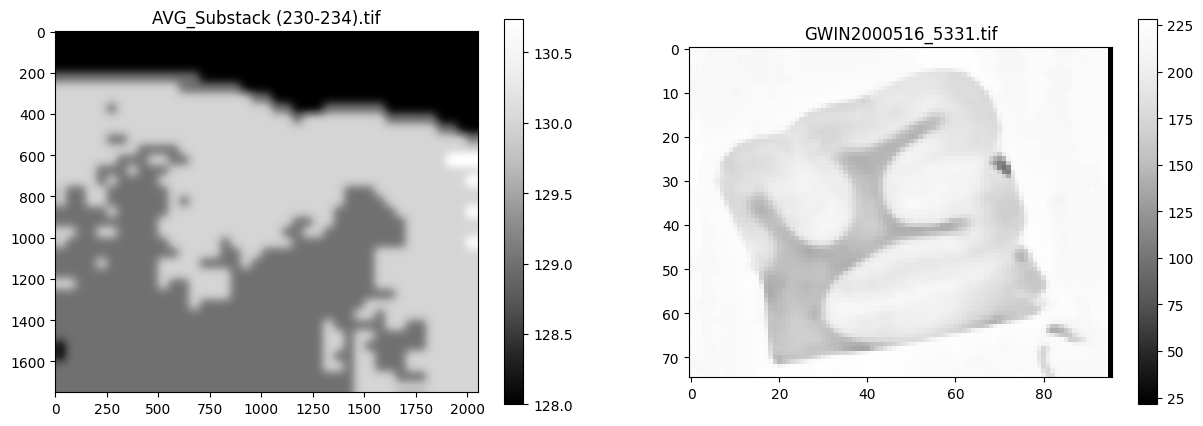

In [49]:
# method 1
downscaled_img1 = downscale_local_mean(median_filtered_img, factors=(int(scaling_height_ratio), int(scaling_width_ratio)))  
print(f"downscaled_image shape: {downscaled_img1.shape}")

compare_plot(mri_img=upscaled_mri_img, slide_img=downscaled_img1)

downscaled_image shape: (73, 89)


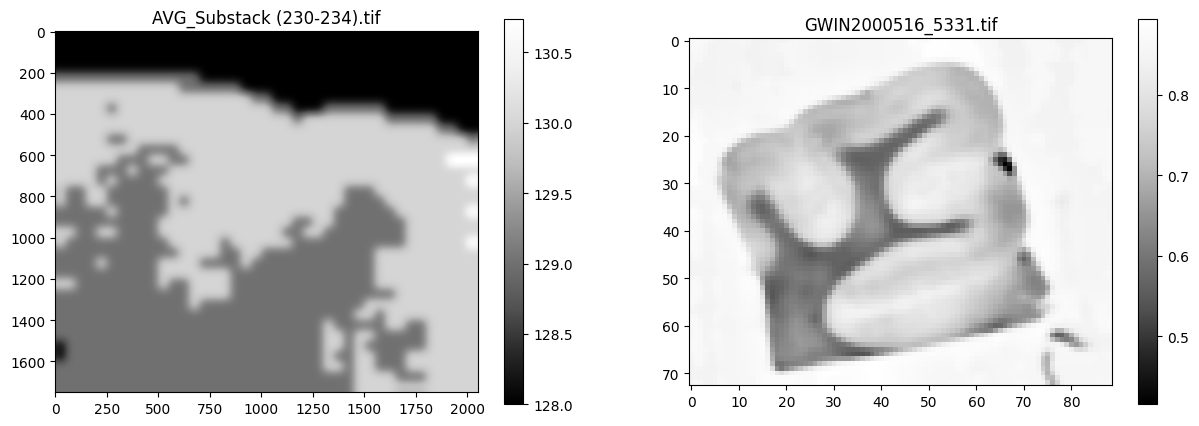

In [48]:
# method 2

# new shape of the microscope image:
new_width = int(median_filtered_img.shape[0] / scaling_width_ratio)
new_height = int(median_filtered_img.shape[1] / scaling_height_ratio)
downscaled_img2 = resize(image = median_filtered_img, output_shape = (new_height, new_width))  

print(f"downscaled_image shape: {downscaled_img2.shape}")

compare_plot(mri_img=upscaled_mri_img, slide_img=downscaled_img2)

# Attention
The MRI resolution was wrong in this notebook, by a factor of 10.
